<a href="https://colab.research.google.com/github/Annasiby/ML/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision
!pip install opencv-python
!pip install matplotlib

In [2]:
from google.colab import files
files.upload()

{}

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashishjangra27/smoking-dataset
!unzip smoking-dataset.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open smoking-dataset.zip, smoking-dataset.zip.zip or smoking-dataset.zip.ZIP.


In [4]:
!pip install kagglehub

In [5]:
import kagglehub

path = kagglehub.dataset_download("sujaykapadnis/smoking")
print(path)


100%|██████████| 63.8M/63.8M [00:02<00:00, 27.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5


In [6]:
import os
os.listdir(path)

['Testing', 'Training', 'Validation']

In [8]:
train_dir = path + "/train"
val_dir   = path + "/valid"   # or validation
test_dir  = path + "/test"

In [9]:
os.listdir(train_dir)

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/train'

In [10]:
import os

print(os.listdir(path))

['Testing', 'Training', 'Validation']


In [11]:
train_dir = path + "/Training"
val_dir   = path + "/Validation"
test_dir  = path + "/Testing"

In [12]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data   = datasets.ImageFolder(val_dir, transform=transform)
test_data  = datasets.ImageFolder(test_dir, transform=transform)

In [13]:
print(train_data.classes)

['Training']


In [14]:
import os
print(os.listdir(train_dir))

['Training']


In [15]:
train_dir = path + "/Training/Training"

In [16]:
val_dir  = path + "/Validation/Validation"
test_dir = path + "/Testing/Testing"

In [17]:
train_data = datasets.ImageFolder(train_dir, transform=transform)
print(train_data.classes)

FileNotFoundError: Couldn't find any class folder in /root/.cache/kagglehub/datasets/sujaykapadnis/smoking/versions/5/Training/Training.

In [18]:
import os
print(os.listdir(path + "/Training"))

['Training']


In [19]:
print(os.listdir(path + "/Training/Training"))

['smoking_0518.jpg', 'smoking_0335.jpg', 'smoking_0049.jpg', 'smoking_0124.jpg', 'notsmoking_0009.jpg', 'notsmoking_0552.jpg', 'notsmoking_0045.jpg', 'smoking_0044.jpg', 'notsmoking_0234.jpg', 'notsmoking_0128.jpg', 'notsmoking_0280.jpg', 'smoking_0112.jpg', 'smoking_0175.jpg', 'notsmoking_0285.jpg', 'notsmoking_0227.jpg', 'smoking_0208.jpg', 'notsmoking_0022.jpg', 'smoking_0319.jpg', 'notsmoking_0267.jpg', 'notsmoking_0485.jpg', 'smoking_0155.jpg', 'notsmoking_0094.jpg', 'smoking_0007.jpg', 'notsmoking_0196.jpg', 'notsmoking_0479.jpg', 'smoking_0248.jpg', 'notsmoking_0146.jpg', 'smoking_0286.jpg', 'smoking_0338.jpg', 'notsmoking_0015.jpg', 'notsmoking_0527.jpg', 'notsmoking_0350.jpg', 'notsmoking_0461.jpg', 'smoking_0492.jpg', 'smoking_0273.jpg', 'smoking_0557.jpg', 'smoking_0483.jpg', 'smoking_0371.jpg', 'smoking_0097.jpg', 'smoking_0278.jpg', 'notsmoking_0559.jpg', 'notsmoking_0311.jpg', 'notsmoking_0123.jpg', 'notsmoking_0375.jpg', 'smoking_0295.jpg', 'notsmoking_0297.jpg', 'smokin

In [20]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SmokingDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        img_path = os.path.join(self.folder, file)

        image = Image.open(img_path).convert("RGB")

        # 🔥 label from filename
        if "smoking" in file.lower():
            label = 1
        else:
            label = 0

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = SmokingDataset(train_dir, transform=transform)

In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [23]:
images, labels = next(iter(train_loader))
print(images.shape, labels)

torch.Size([32, 3, 224, 224]) tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])


In [24]:
if "notsmoking" in file.lower():
    label = 0
else:
    label = 1

NameError: name 'file' is not defined

In [25]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SmokingDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]   # ✅ file defined here
        img_path = os.path.join(self.folder, file)

        image = Image.open(img_path).convert("RGB")

        # ✅ FIXED LABEL LOGIC (inside function)
        if "notsmoking" in file.lower():
            label = 0
        else:
            label = 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [26]:
train_data = SmokingDataset(train_dir, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))
print(labels)

tensor([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 0, 1, 0])


In [27]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.1MB/s]


In [28]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 18.0448
Epoch 2, Loss: 10.2725
Epoch 3, Loss: 6.5670
Epoch 4, Loss: 3.4886
Epoch 5, Loss: 2.3360


In [29]:
!pip install scikit-learn


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:   # you can also use test_loader if available
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [31]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Confusion Matrix:\n", cm)

Accuracy : 0.9231843575418994
Precision: 0.8668280871670703
Recall   : 1.0
F1 Score : 0.9286640726329443
Confusion Matrix:
 [[303  55]
 [  0 358]]


In [32]:
for images, labels in test_loader:

SyntaxError: incomplete input (1461625561.py, line 1)

In [33]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Accuracy:", accuracy)

Accuracy: 92.31843575418995


In [34]:
error_rate = 1 - accuracy
print("Error %:", error_rate * 100)

Error %: -9131.843575418994


In [35]:
for epoch in range(5):

SyntaxError: incomplete input (1688906250.py, line 1)

In [36]:
for epoch in range(5):

SyntaxError: incomplete input (1688906250.py, line 1)

In [37]:
for epoch in range(5):
    print("Epoch:", epoch+1)

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


In [38]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 2.5974
Epoch 2, Loss: 2.9231
Epoch 3, Loss: 2.3781
Epoch 4, Loss: 3.7768
Epoch 5, Loss: 2.1495


In [39]:
accuracy, precision, recall, f1

(92.31843575418995, 0.8668280871670703, 1.0, 0.9286640726329443)

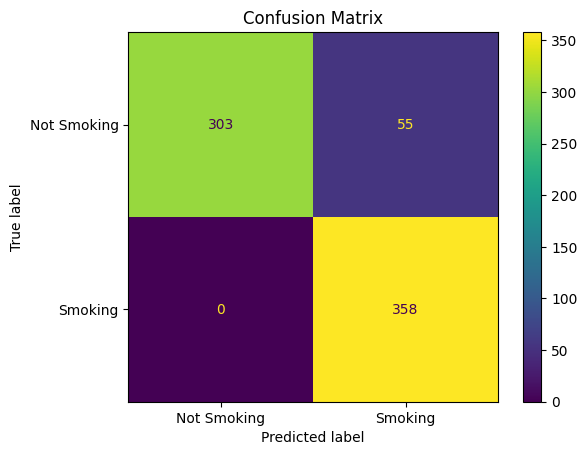

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Smoking", "Smoking"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [41]:
losses = []

for epoch in range(10):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1.7962
Epoch 2, Loss: 1.0273
Epoch 3, Loss: 0.8513
Epoch 4, Loss: 1.1530
Epoch 5, Loss: 2.3489
Epoch 6, Loss: 1.4753
Epoch 7, Loss: 2.8065
Epoch 8, Loss: 2.4674
Epoch 9, Loss: 4.1308
Epoch 10, Loss: 2.9726


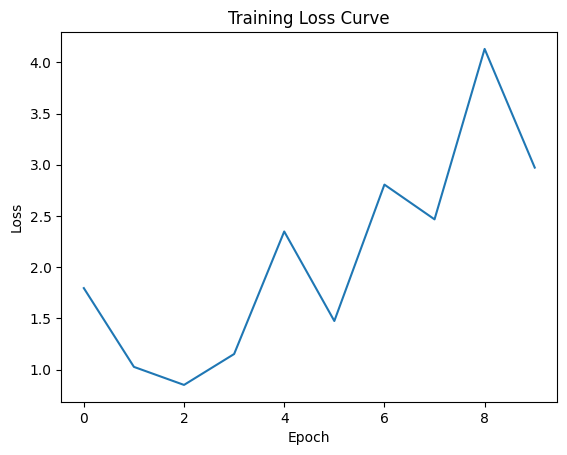

In [42]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [43]:
from google.colab import files
uploaded = files.upload()

Saving i.jpg to i.jpg


In [44]:
from PIL import Image
import torch

def predict_image(image_path, model):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # add batch dimension
    image = image.to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    if predicted.item() == 1:
        return "Smoking 🚬"
    else:
        return "Not Smoking 🚫"

In [46]:
result = predict_image("i.jpg", model)
print("Prediction:", result)

Prediction: Smoking 🚬


In [47]:
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images.jpg


In [50]:
result = predict_image("images.jpg", model)
print("Prediction:", result)

Prediction: Not Smoking 🚫


In [49]:
from google.colab import files
uploaded = files.upload()

Saving causes-mouth-cancer-in-a-non-smoker-scaled.webp to causes-mouth-cancer-in-a-non-smoker-scaled.webp


In [51]:
from google.colab import files
uploaded = files.upload()

Saving causes-mouth-cancer-in-a-non-smoker-scaled.webp to causes-mouth-cancer-in-a-non-smoker-scaled (1).webp


In [52]:
from PIL import Image
import torch

def predict_image(image_path, model):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # add batch dimension
    image = image.to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    if predicted.item() == 1:
        return "Smoking 🚬"
    else:
        return "Not Smoking 🚫"

In [53]:
result = predict_image("new2.webp", model)
print("Prediction:", result)

Prediction: Not Smoking 🚫


In [54]:
import os

train_count = len(os.listdir(train_dir))
val_count   = len(os.listdir(val_dir))
test_count  = len(os.listdir(test_dir))

total = train_count + val_count + test_count

print("Training images :", train_count)
print("Validation images:", val_count)
print("Testing images  :", test_count)
print("Total images    :", total)

Training images : 716
Validation images: 180
Testing images  : 224
Total images    : 1120
